# 00 · Start here — what is this dataset?

**Welcome!** These notebooks walk you from "I've never seen ocean data" to "I can
load it, plot it, remove the tide, and analyse currents". No prior oceanography
or seismology needed.

There are **two separate datasets** here:

* **`tidal/`** — a **pressure gauge** (+ temperature). Notebooks **00–04** use this.
* **`currentmeter/`** — a **current meter** measuring water **velocity**.
  Notebook **05** uses this.

This first notebook explores the **`tidal/` pressure-gauge dataset**.

> 🎯 **What you'll learn in this notebook**
>
> - What the instruments measured and where
> - How the files are named and organised (the *SEED* convention)
> - The two **channels** in this dataset (pressure vs temperature)
> - How to build a quick *catalog* of 30,000 files without opening them
> - How to see, at a glance, which station has data on which dates

## Background: where does this data come from?

These are measurements from instruments sitting on the **seafloor** off the
Pacific Northwest (USA), part of the **Ocean Observatories Initiative (OOI)** —
a network of cabled underwater sensors that stream data continuously for years.

Each instrument records two things we care about here:

1. **Pressure** — the weight of the water column above the sensor. When the
   tide comes in, there's *more* water overhead, so pressure rises. Pressure is
   therefore a direct stand-in for **sea level / tides**.
2. **Temperature** — how warm the near-bottom seawater is.

The data is stored in a file format called **mSEED** (miniSEED), which was
invented for seismometers but is widely used for any continuous sensor stream.
We don't need to know its internals — the `obspy` library reads it for us.

> 📖 **Time series** — a sequence of measurements taken at successive times. Almost everything in these notebooks is a time series: a column of *values* paired with a column of *timestamps*.

## How the files are named

Every file holds **one channel, for one station, for one day**. The name packs
in all the metadata, following the **SEED** naming convention:

```
OO . AXBA1 . 10 . UDO . 2014 . 244 . 00.00.06.735 - 2014.244.23.59.51.684 .mseed
│    │       │    │      │      │     └ start time (HH.MM.SS.mmm)      └ end time
│    │       │    │      │      └ day-of-year (244 = 1 Sep)
│    │       │    │      └ year
│    │       │    └ CHANNEL code (the important bit — see below)
│    │       └ location code
│    └ STATION  (AXBA1 = "Axial Base")
└ network (OO = Ocean Observatories)
```

> 📖 **Day-of-year (DOY)** — the day's number within the year, 1–365 (or 366). DOY 1 = 1 Jan, DOY 244 = 1 Sep. Common in geoscience because it sorts cleanly. We convert it to a normal date for you.

> 📖 **UTC** — Coordinated Universal Time — the single global clock all this data uses (no time zones, no daylight saving). Every timestamp here is UTC.

## The channel code = which variable

The 3-letter **channel** tells you what the numbers mean. The last two letters
matter most:

| channel ends in | variable | rough values | think of it as |
|-----------------|----------|--------------|----------------|
| `DO` (e.g. `UDO`, `LDO`) | **pressure** (→ dbar) | ~790–2960 dbar | the tide / sea level |
| `K1` (e.g. `UK1`, `LK1`) | **temperature** | ~1.8–4 °C | bottom-water warmth |

The **first** letter is just the speed the sensor sampled at: `U` ≈ one reading
every **15 seconds**, `L` = one reading every **1 second**.

> ℹ️ **A bit of history about the folders.** This pressure-gauge data originally
> arrived duplicated in **two byte-identical folders** (`tidal/` and
> `currentmeter/`). The duplicate was later removed and `currentmeter/` was
> repurposed for the genuine **current-meter** dataset (water velocity — see
> notebook 05). So in *this* notebook the two "types of data" are the two
> **channels** — pressure and temperature — within the `tidal/` folder.
> `oceanlib` auto-selects whichever pressure-gauge folder is present.

## Let's look. First, load the toolkit and our helper module.

In [1]:
# --- Standard scientific-Python toolkit -----------------------------------
import warnings; warnings.filterwarnings("ignore")  # hide harmless library chatter
import numpy as np                 # arrays & math
import pandas as pd                # labelled time series (our main data type)
import matplotlib.pyplot as plt    # plotting
import matplotlib.dates as mdates  # nice date axes
import oceanlib as ol              # OUR helper module (sits next to this notebook)

# Make every plot a sensible default size with a light grid.
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})
pd.set_option("display.max_rows", 40)

print("Reading data from:", ol.DATA_DIR)
print("Stations available:", ol.STATIONS)

Reading data from: /Users/quakehunter/Documents/data_exploration/tidal
Stations available: ['AXBA1', 'HYSB1', 'HYS14']


### Build a catalog from the filenames

Opening all 30,000 files would be slow. Instead we **parse the filenames** to
build a table (a pandas `DataFrame`) — one row per file — which is instant.
`oceanlib.build_catalog()` does this for us.

In [2]:
cat = ol.build_catalog()                       # one row per file, from names only
print(f"{len(cat):,} files spanning {cat.date.min().date()} → {cat.date.max().date()}")
cat.head()      # peek at the first few rows

29,872 files spanning 2014-09-01 → 2025-05-01


,sta,loc,cha,year,doy,date,variable,path
0,AXBA1,10,UDO,2014,244,2014-09-01,pressure,/Users/quakehunter/Documents/data_exploration/...
1,AXBA1,10,UDO,2014,245,2014-09-02,pressure,/Users/quakehunter/Documents/data_exploration/...
2,AXBA1,10,UDO,2014,246,2014-09-03,pressure,/Users/quakehunter/Documents/data_exploration/...
3,AXBA1,10,UDO,2014,247,2014-09-04,pressure,/Users/quakehunter/Documents/data_exploration/...
4,AXBA1,10,UDO,2014,247,2014-09-04,pressure,/Users/quakehunter/Documents/data_exploration/...


> 👀 **What you're seeing**
>
> A table where each row is one daily file. Key columns: `sta` (station), `cha` (channel), `date`, and `variable` — which we derived from the channel code so you can filter by 'pressure' or 'temperature' directly.

### How many files do we have, per station and channel?

In [3]:
counts = cat.groupby(["sta", "cha", "variable"]).size().rename("files").reset_index()
counts

,sta,cha,variable,files
0,AXBA1,UDO,pressure,4272
1,AXBA1,UK1,temperature,4272
2,HYS14,LDO,pressure,5232
3,HYS14,LK1,temperature,5232
4,HYS14,UDO,pressure,1247
5,HYS14,UK1,temperature,1247
6,HYSB1,LDO,pressure,2503
7,HYSB1,LK1,temperature,2503
8,HYSB1,UDO,pressure,1682
9,HYSB1,UK1,temperature,1682


> 👀 **What you're seeing**
>
> Three stations (AXBA1, HYSB1, HYS14). Notice some stations list the **same variable twice** under different channels — e.g. HYS14 has both `UDO` (15 s) and `LDO` (1 s) pressure. That's the same quantity sampled at two speeds during different deployments.

`oceanlib` has a helper to show exactly which channels carry each variable, and how many files each has:

In [4]:
for sta in ol.STATIONS:
    p = ol.channels_for(sta, "pressure")
    t = ol.channels_for(sta, "temperature")
    print(f"{sta:6s}  pressure: {dict(p)}   temperature: {dict(t)}")

AXBA1   pressure: {'UDO': np.int64(4272)}   temperature: {'UK1': np.int64(4272)}
HYSB1   pressure: {'LDO': np.int64(2503), 'UDO': np.int64(1682)}   temperature: {'LK1': np.int64(2503), 'UK1': np.int64(1682)}


HYS14   pressure: {'LDO': np.int64(5232), 'UDO': np.int64(1247)}   temperature: {'LK1': np.int64(5232), 'UK1': np.int64(1247)}


### When does each station have data?

A common first question with any sensor archive: *what are the gaps?*
Instruments get recovered, batteries die, deployments move. This plot puts a
tick mark on every day each station/channel has a file.

saved /Users/quakehunter/Documents/data_exploration/figures/00_coverage.png


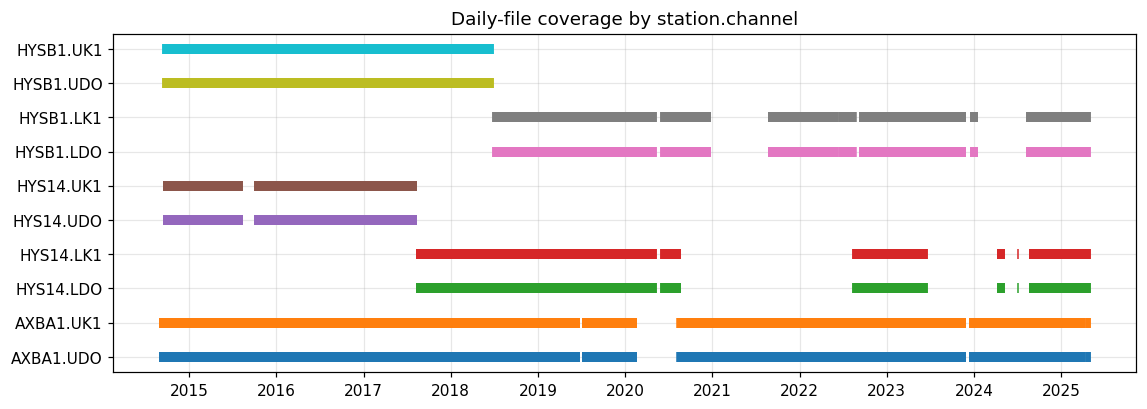

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
labels = []
for i, (key, g) in enumerate(cat.groupby(["sta", "cha"])):
    labels.append(".".join(key))
    ax.plot(g.date, np.full(len(g), i), "|", ms=6)   # one '|' tick per available day
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_title("Daily-file coverage by station.channel")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ol.savefig(fig, "00_coverage.png"); plt.show()

> 👀 **What you're seeing**
>
> Solid horizontal bands = continuous data; white gaps = missing days. This is your map for choosing *when* to look — you want a long solid stretch. (We've pre-picked good ones for you; see the end of this notebook.)

### Data volume per year

saved /Users/quakehunter/Documents/data_exploration/figures/00_files_per_year.png


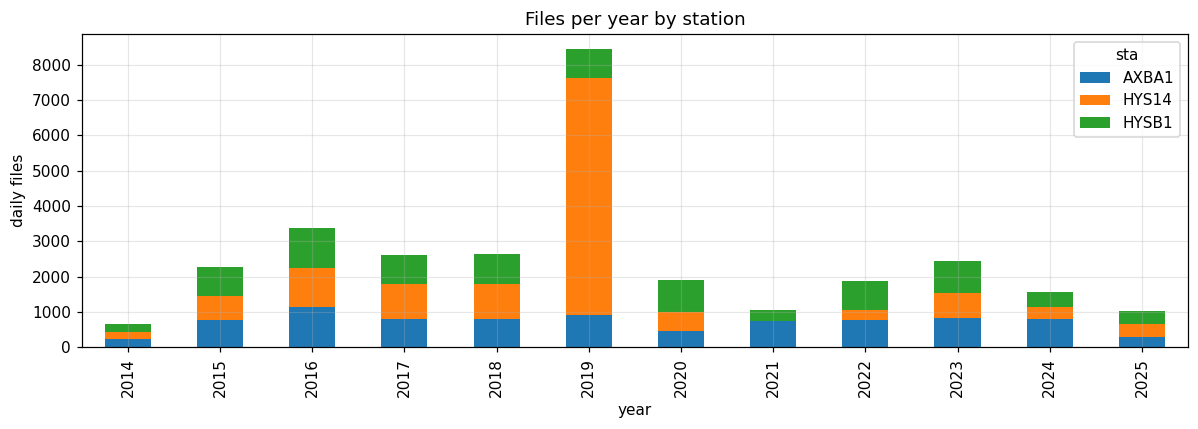

sta,AXBA1,HYS14,HYSB1
year,,,
2014,234,206,216
2015,784,672,814
2016,1132,1118,1138
2017,802,990,816
2018,808,994,844
2019,916,6704,828
2020,452,548,902
2021,756,0,308
2022,758,302,802


In [6]:
piv = cat.assign(year=cat.date.dt.year).pivot_table(
    index="year", columns="sta", values="path", aggfunc="count", fill_value=0)
ax = piv.plot.bar(stacked=True, figsize=(11, 4))
ax.set_ylabel("daily files"); ax.set_title("Files per year by station")
plt.tight_layout(); ol.savefig(ax.figure, "00_files_per_year.png"); plt.show()
piv

### Pre-picked "good" windows

To save you hunting for gap-free stretches, `oceanlib` ships a few long,
continuous windows — one per station. The later notebooks open on these by
default.

In [7]:
ol.DEMO

{'AXBA1': {'channel': 'UDO', 'start': '2015-03-09', 'end': '2016-07-11'},
 'HYSB1': {'channel': 'LDO', 'start': '2019-07-29', 'end': '2020-05-09'},
 'HYS14': {'channel': 'LDO', 'start': '2018-10-02', 'end': '2019-07-26'}}

> ✏️ **Try it yourself**
>
> 1. Change `cat.head()` to `cat.tail()` — what are the *most recent* files?
> 2. Filter the catalog to just one station: `cat[cat.sta == 'HYSB1']`.
> 3. Count how many *years* HYS14 covers: `cat[cat.sta=='HYS14'].date.dt.year.nunique()`.

> ✅ **Recap**
>
> You now know the data is OOI seafloor pressure & temperature, stored as daily mSEED files named by the SEED convention, with two real data types (pressure `*DO`, temperature `*K1`). You can build a catalog and read the coverage map.
>
> ➡️ **Next:** `01_signals_separately.ipynb` — load and actually plot each variable.

---
## 📖 Mini-glossary (refer back any time)

| term | meaning |
|------|---------|
| **mSEED** | the binary file format the data is stored in; `obspy` reads it |
| **channel** | 3-letter code naming the variable + sample rate (`UDO`, `LK1`, …) |
| **station** | a fixed instrument site (`AXBA1`, `HYSB1`, `HYS14`) |
| **sample rate** | how often a reading is taken (here 1 s or 15 s) |
| **dbar** | decibar, the unit of pressure we report; in seawater 1 dbar ≈ 1.02 m of depth |
| **counts** | the raw integer the instrument stores; `oceanlib` converts pressure counts → dbar for you |
| **tide** | the regular rise & fall of sea level caused by the Moon & Sun |
| **residual** | what's left after removing the tide — the "weather"/ocean signal |
| **catalog** | our table of files (built from names, no data read) |